# LLDVE runs: soy

Model 3 on `master_panel_soy.csv`, same five states as corn. First only the four rainfed states pooled. Nebraska has no county soy yields before 1960, so it fails the missing-years rule almost everywhere; keep that in mind before switching on a Nebraska run. Shared code is in `lldve_runs.py`.

## Imports

In [16]:
import os
import time
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import lldve_runs
from methods import LLDVE_test
import model_builder

# pick up edits to the modules without restarting the kernel
importlib.reload(model_builder)
importlib.reload(LLDVE_test)
importlib.reload(lldve_runs)

start_timer = time.time()

## Settings

Everything that can be changed is here. The run tags are built as `<states>_<model>_<season>_logY_<processing>X`, the same format as the thesis results.

In [ ]:
# --- data ---
MASTER_PANEL = "master_panel_soy.csv"
START_YEAR = 1951          # nclimgrid-daily starts here, nothing to model before
END_YEAR = 2024          # must equal END_YEAR in pre_diagnostics/missing_data.py. 2024 = thesis window; 2025 is still incomplete on the yield side
MAX_MISSING_YEARS = 4      # must equal MISSING_YEAR_TOLERANCE in pre_diagnostics/missing_data.py (Zipper et al. 2016, same as thesis)

# --- model ---
SETTINGS = {
    'model_id': 'model_3',          # GDD + KDD + PREC + PREC^2 + KDD x PREC, paper Eq. 6
    'season': 'GS',                 # 1 April - 30 September
    'processing_type': 'anomaly',   # regressors as anomalies vs the county's 1981-2010 mean
    'saving_path': 'paper_main_results/soy',

    'bandwidth_method': 'manual',   # 'manual' (uses manual_h) | 'plmcv' | 'louocv' | 'aic' | 'gcv'
    # fixed bandwidth for 'manual'. The thesis PLMCV values were 0.26-0.34 (per run in lldve_run_corn); still to be revisited
    'manual_h': 0.30,
    'B': 149,                       # bootstrap replications; 149 for checking, 1499 for the final runs
    'run_bootstrap': True,
    'plot_coeffs': False,
    'plot_mean_fits': True,
    'save_draws': True,
}

## Load the panel and select counties

`select_regions` keeps the year window, drops counties without any yield, and applies the missing-years rule. The table shows every county that was dropped and why.

In [18]:
df_all = lldve_runs.read_master_panel(MASTER_PANEL)

# the county filter was applied by pre_diagnostics/missing_data.py; stop if it used another window than this notebook
panel_filter = lldve_runs.check_panel_filter(MASTER_PANEL, START_YEAR, END_YEAR, MAX_MISSING_YEARS)

# year window, plus a re-check of the filter: with matching settings nothing is dropped here
df_model, dropped = lldve_runs.select_regions(
    df_all,
    start_year=START_YEAR,
    end_year=END_YEAR,
    max_missing_years=MAX_MISSING_YEARS,
)

print("\ncounties kept per state:")
print(df_model.groupby(df_model['fips_full'].str[:2])['fips_full'].nunique().to_string())
dropped

Loaded master_panel_soy.csv: 33165 rows, 335 counties, years 1927-2025


ValueError: Panel filter and notebook settings differ:
  end_year: panel 2024, notebook 2022
Change the notebook settings, or rerun missing_data.py + anomalies.py with the new window.

## Runs

One entry per run: label -> list of state codes (`None` = every state in the panel). The label becomes the first part of the output folder name.

In [ ]:
RUNS = {
    '17':          ['17'],                      # Illinois, first test run (same state as the corn test)
    #'17_18_19_27': ['17', '18', '19', '27'],    # the four rainfed states pooled
    # per state and Nebraska, switch on when wanted:
    # '18': ['18'], '19': ['19'], '27': ['27'], '31': ['31'],
}

## Estimate

Each run writes its own folder under `saving_path`: `mTheta_hat.csv`, `vAlpha_hat.csv`, `h_optimal.txt`, fitted values and residuals, the bootstrap CI CSVs and figures, R2 and explained-variation output.

STARTING RUN: 17_18_19_27_model_3_GS_logY_anomalyX
1951
Using 'log_value' as the dependent variable (Y) for this run.
Data prepared for 335 regions and 74 years.
Building variables for Model 3, Season: GS...
  Using 'anomaly' versions of regressors (suffix: '_anom').


  Creating interaction term: KDD * PREC
--- Running LLDVE for State: 17_18_19_27, Model model_3,             Season: GS, Note: logY_anomalyX ---
Results will be saved in: paper_main_results/soy\17_18_19_27_model_3_GS_logY_anomalyX
Saving key input matrices for this run...
Using manual bandwidth h = 0.3
Optimal bandwidth selected/used: 0.3000
Estimating LLDVE model...
Saved mTheta_hat and vAlpha_hat.
Calculating final fitted values and residuals...
Saved fitted values to: paper_main_results/soy\17_18_19_27_model_3_GS_logY_anomalyX\fitted_values_final.csv
Saved residuals to: paper_main_results/soy\17_18_19_27_model_3_GS_logY_anomalyX\residuals_final.csv
Plotting mean fits...
Saved y-mean plot to: paper_main_results/soy\17_18_19_27_model_3_GS_logY_anomalyX\figures\ymean_plot_17_18_19_27_model_3_GS_logY_anomalyX


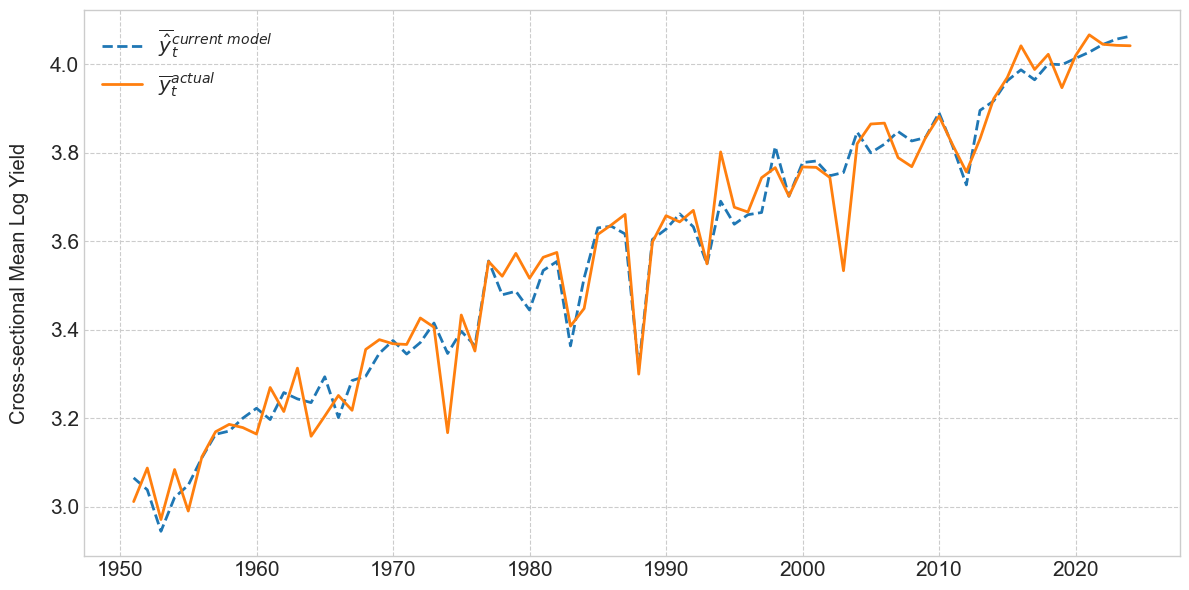

done
Performing Bootstrap and Plotting Confidence Intervals...
Started Parallel Bootstrap Job with 149 replications...
Bootstrap replications completed in 1853.12 seconds.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


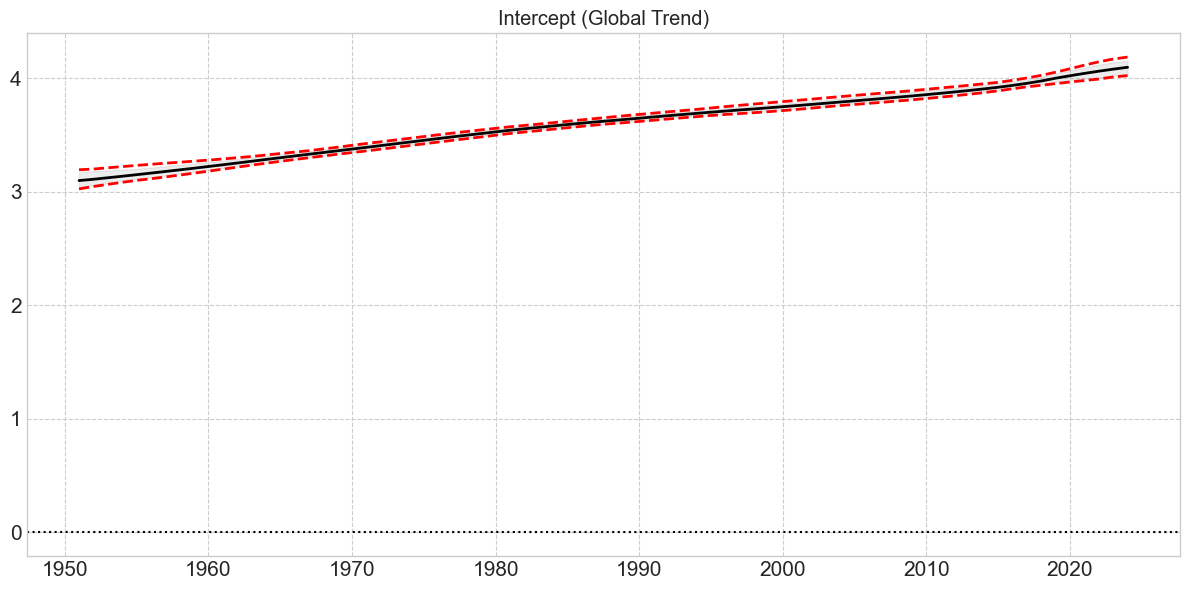

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


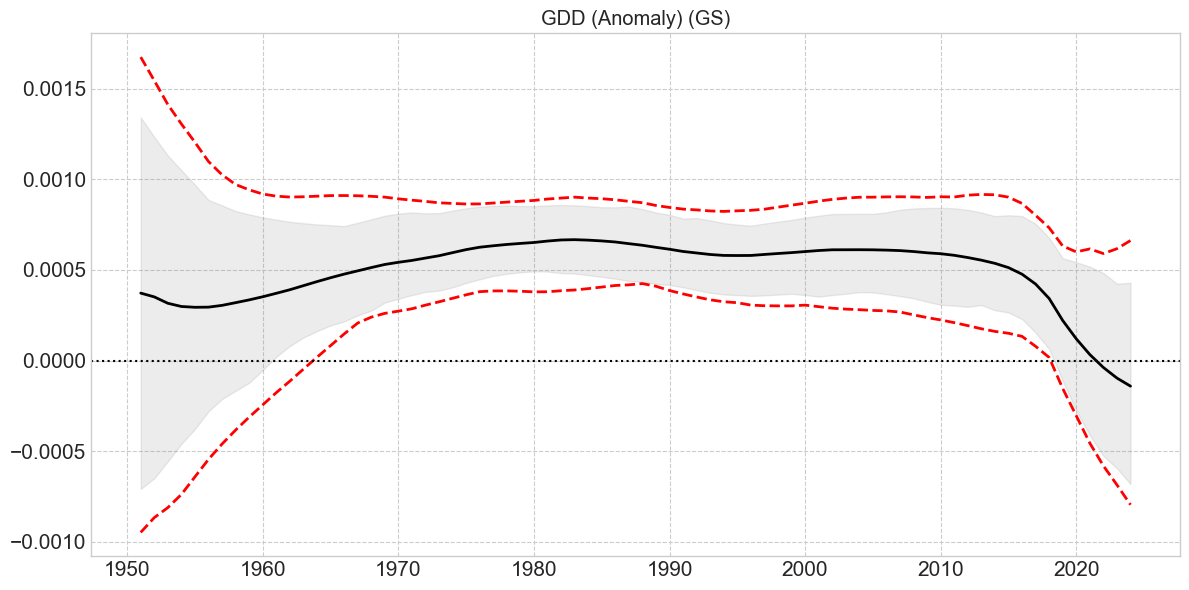

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


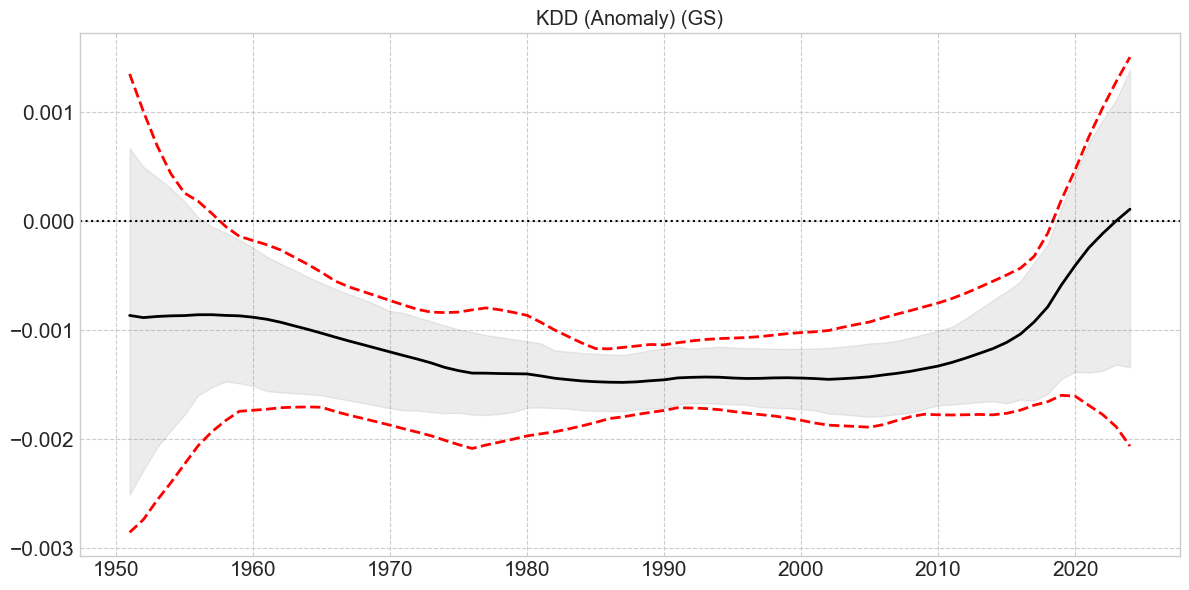

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


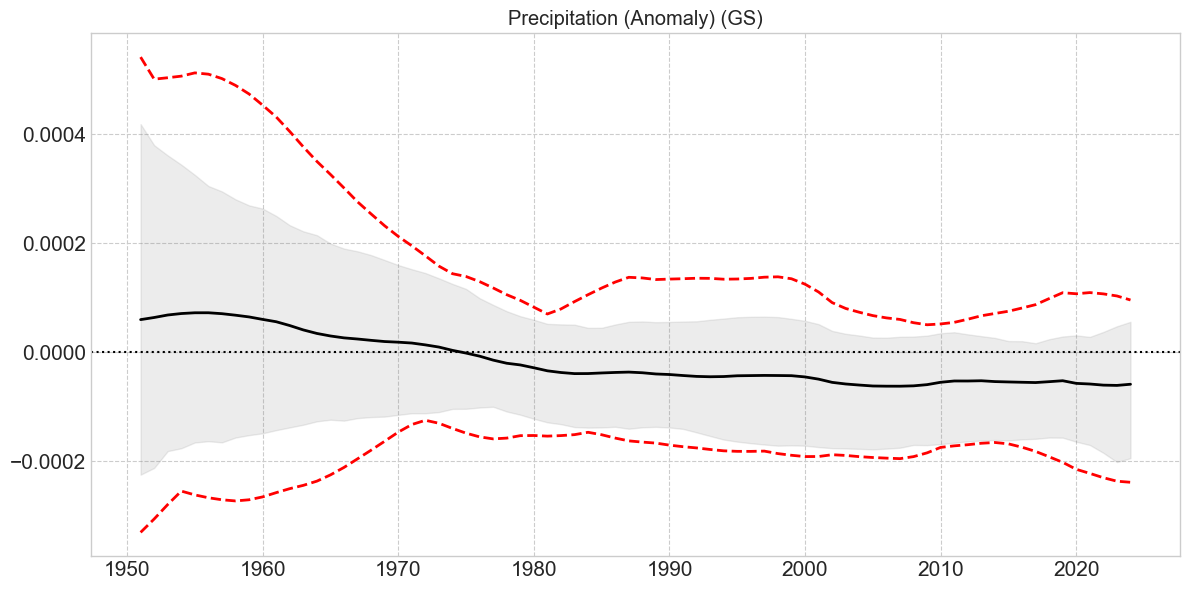

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


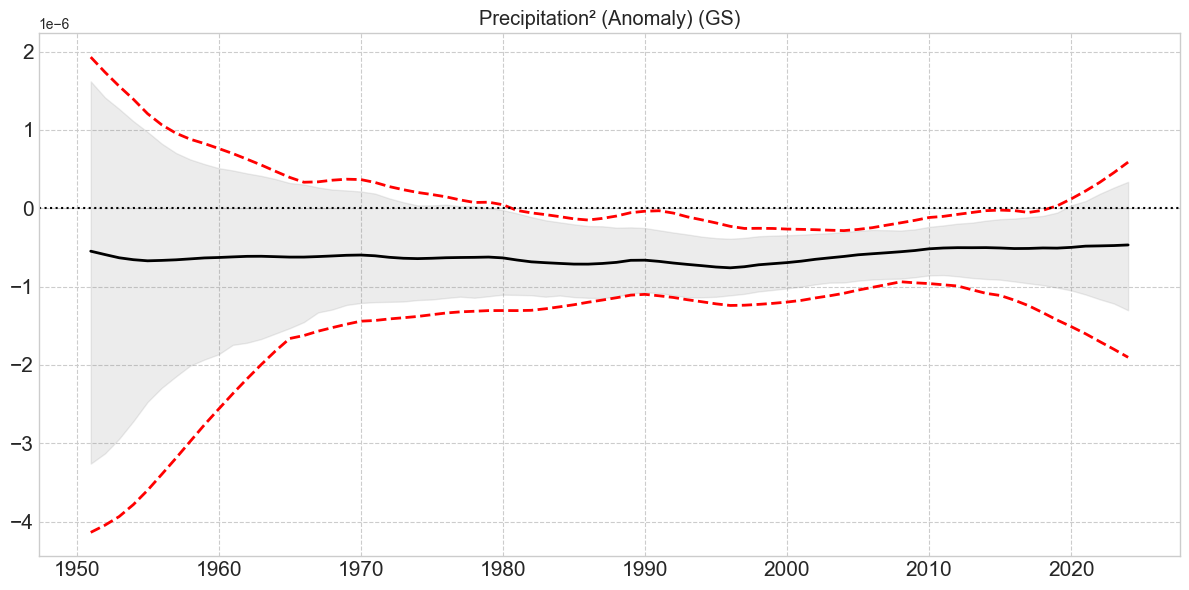

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


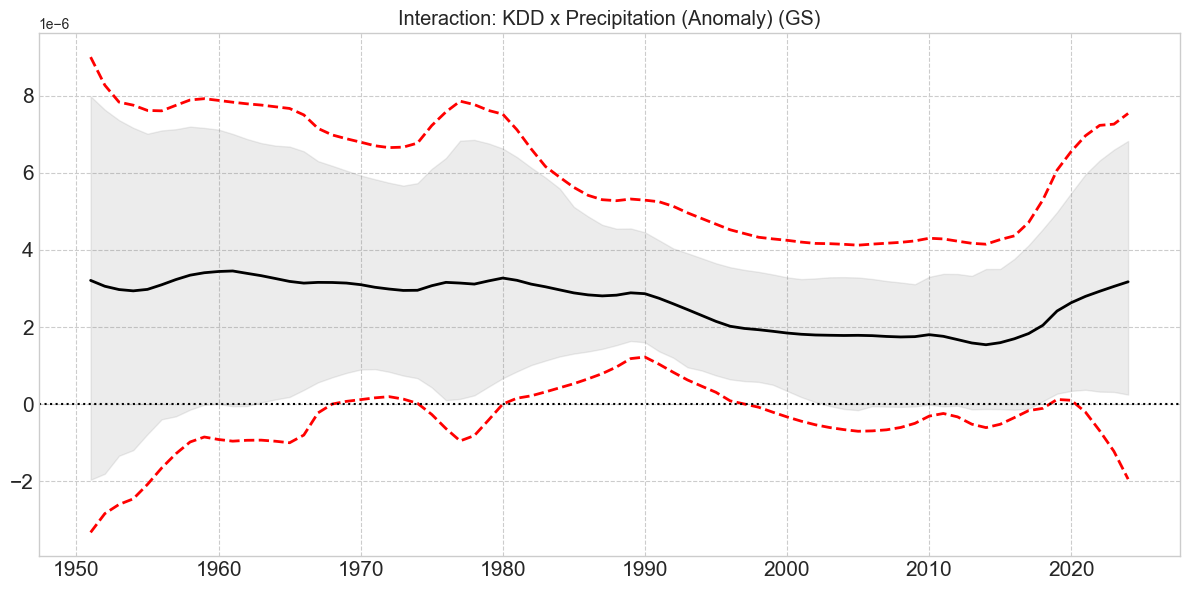

Saved full bootstrap draws and oversmoothed coefficients.
--- Completed LLDVE for State: 17_18_19_27, Model: model_3,             Season: GS, Note: logY_anomalyX ---

LLDVE done. Results in: paper_main_results/soy\17_18_19_27_model_3_GS_logY_anomalyX

--- Starting All R-squared Analyses for: 17_18_19_27_model_3_GS_logY_anomalyX ---
Calculating Time-Varying R-squared for: 17_18_19_27_model_3_GS_logY_anomalyX...
Saved time-varying R-squared to: paper_main_results/soy\17_18_19_27_model_3_GS_logY_anomalyX\csv_data_R2\r_squared_time_varying_17_18_19_27_model_3_GS_logY_anomalyX.csv
Saved time-varying R-squared plot to: paper_main_results/soy\17_18_19_27_model_3_GS_logY_anomalyX\figures_R2\r_squared_time_varying_17_18_19_27_model_3_GS_logY_anomalyX.eps


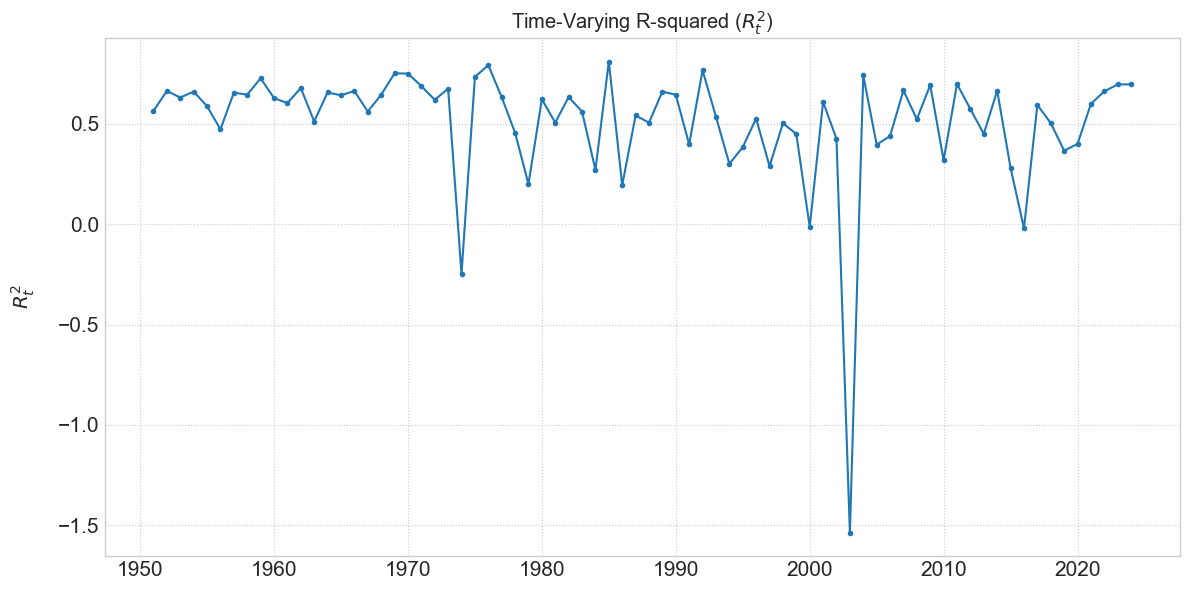

Calculating Pooled R-squared...
Pooled R-squared: 0.8718
Calculating Per-Region R-squared for: 17_18_19_27_model_3_GS_logY_anomalyX...
Saved per-region R-squared to: paper_main_results/soy\17_18_19_27_model_3_GS_logY_anomalyX\csv_data_R2\r_squared_per_region_17_18_19_27_model_3_GS_logY_anomalyX.csv
Plotting Per-Region R-squared for: 17_18_19_27_model_3_GS_logY_anomalyX...
Saved per-region R-squared plot to: paper_main_results/soy\17_18_19_27_model_3_GS_logY_anomalyX\figures_R2\r_squared_per_region_17_18_19_27_model_3_GS_logY_anomalyX.eps


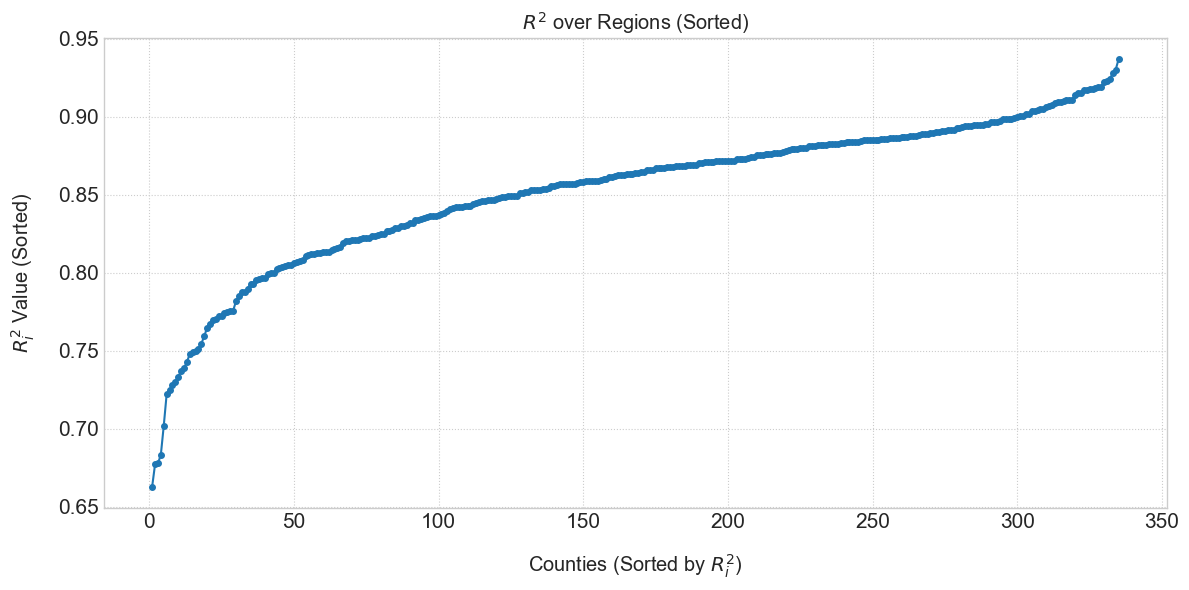

--- Completed All R-squared Analyses for: 17_18_19_27_model_3_GS_logY_anomalyX ---
Calculating Explained Variation Decomposition for: 17_18_19_27_model_3_GS_logY_anomalyX...
Saved 1Y explained variation ratios to: paper_main_results/soy\17_18_19_27_model_3_GS_logY_anomalyX\csv_data_ExplVar\explained_variation_1Y_ratios_17_18_19_27_model_3_GS_logY_anomalyX.csv
Saved 3Y explained variation ratios to: paper_main_results/soy\17_18_19_27_model_3_GS_logY_anomalyX\csv_data_ExplVar\explained_variation_3Y_avg_17_18_19_27_model_3_GS_logY_anomalyX.csv
Saved 6Y explained variation ratios to: paper_main_results/soy\17_18_19_27_model_3_GS_logY_anomalyX\csv_data_ExplVar\explained_variation_6Y_avg_17_18_19_27_model_3_GS_logY_anomalyX.csv


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved explained variation plot (Global Trend) to: paper_main_results/soy\17_18_19_27_model_3_GS_logY_anomalyX\figures_ExplVar\explained_variation_trend_17_18_19_27_model_3_GS_logY_anomalyX.eps


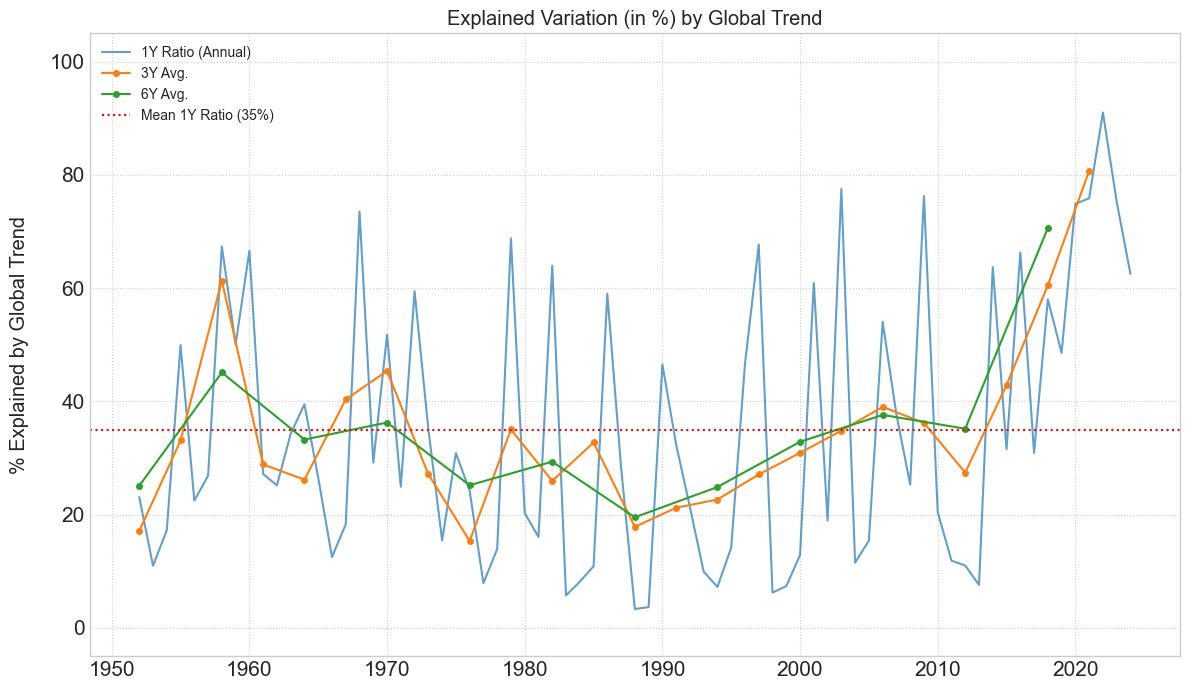

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved explained variation plot (Weather Components) to: paper_main_results/soy\17_18_19_27_model_3_GS_logY_anomalyX\figures_ExplVar\explained_variation_weather_17_18_19_27_model_3_GS_logY_anomalyX.eps


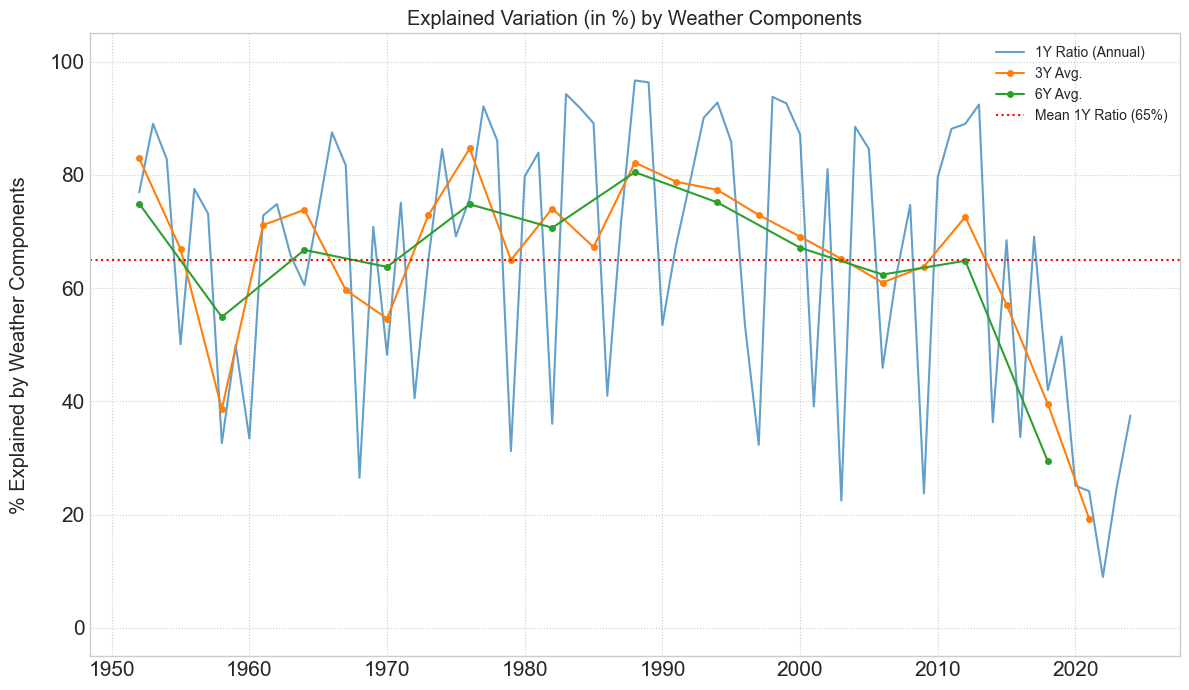

--- RUN COMPLETE: 17_18_19_27_model_3_GS_logY_anomalyX (N = 335, T = 74) ---


All runs done in 32.7 minutes.


,N,T,h
17_18_19_27,335.0,74.0,0.3


In [ ]:
results = {}
for label, states in RUNS.items():
    results[label] = lldve_runs.run_lldve(
        df_model, states, SETTINGS, states_label=label,
        run_r_squared=True, run_explained_variation=True,
    )

print(f"\nAll runs done in {(time.time() - start_timer) / 60:.1f} minutes.")

# short overview of what was estimated
summary = []
for label, res in results.items():
    summary.append({'run': label, 'N': res['N'], 'T': res['T'], 'h': res['h_optimal']})

pd.DataFrame(summary)

## Coefficient paths

Saved paper_main_results/soy\coefficient_paths.png


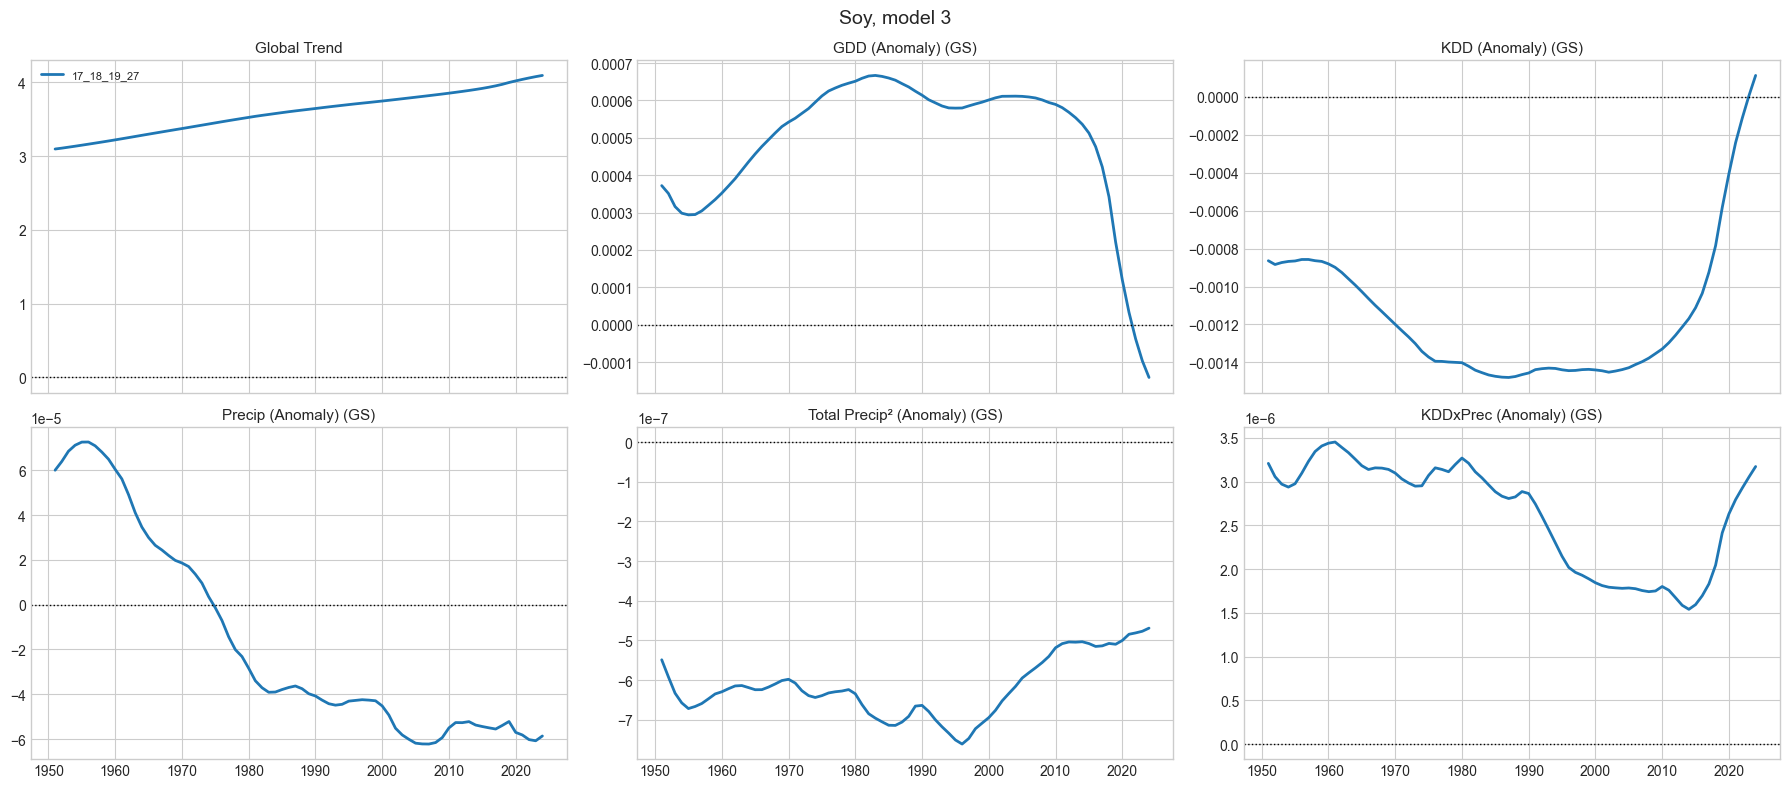

In [ ]:
lldve_runs.plot_coefficient_paths(
    results,
    title="Soy, model 3",
    save_path=os.path.join(SETTINGS['saving_path'], "coefficient_paths.png"),
)